In [8]:
import sys
print(sys.executable)

/home/gona/miniconda3/envs/jpt-plots/bin/python


In [9]:
import os
import tarfile
import shutil
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


In [ ]:
# ===================== CONFIG =====================
query = "q1"
failure = "/srv/nfs/flink/nexmark/scalability/"
base_dir = Path(failure + query + "p15")
output_dir = Path("analysis_output") / failure / query
window_seconds = 5
# ==================================================

In [11]:
print("[SCAN] Using existing extracted data (no tar files)")

# Option 1: data is directly inside base_dir
part_files = sorted(glob.glob(str(base_dir / "part-*")))

# Option 2 (more robust): search recursively
if not part_files:
    part_files = sorted(glob.glob(str(base_dir / "**/part-*"), recursive=True))

print(f"[INFO] Found {len(part_files)} part files")

if not part_files:
    print(f"[ERROR] No part files found under {base_dir}")
    exit(1)

[SCAN] Using existing extracted data (no tar files)
[INFO] Found 32 part files


In [12]:
def compute_latency_summary(df):
    return {
        "avg": df["latency_ms"].mean(),
        "p50": df["latency_ms"].quantile(0.50),
        "p95": df["latency_ms"].quantile(0.95),
        "p99": df["latency_ms"].quantile(0.99),
    }

In [13]:
def parse_part_file(pf):
    rows = []
    bad = 0

    print(f"[FILE] Processing: {os.path.basename(pf)}")
    max_errors_to_show = 5
    error_count = 0
    with open(pf, "r", errors="ignore") as f:
        for line_num, line in enumerate(f, 1):
            parts = line.rstrip("\n").split(",", 5)

            if len(parts) < 6:
                bad += 1
                print(f"[WARN] Line {line_num}: insufficient columns -> {line.strip()}")
                continue

            auction, bidder, price, event_time, processed_time, extra= parts

            try:
                rows.append({
                    "auction": int(auction),
                    "bidder": int(auction),
                    "price": float(price),
                    "event_time": event_time,
                    "processed_time": processed_time,
                    "extra": extra
                })

            except Exception as e:
                bad += 1
                if error_count < max_errors_to_show:
                    print(f"[ERROR] Line {line_num}: {e}")
                    print(f"        data: {line.strip()}")
                    error_count += 1

    print(f"    -> parsed rows: {len(rows)} | bad rows: {bad}")
    return pd.DataFrame(rows)

In [14]:
print("\n[SCAN] Using flat dataset (no nodes)")

part_files = sorted(glob.glob(str(base_dir / "**/part-*"), recursive=True))
print(f"[INFO] Found {len(part_files)} part files")

if not part_files:
    print(f"[ERROR] No part files found under {base_dir}")
    exit(1)

dfs = []

for pf in part_files:
    df_part = parse_part_file(pf)
    if not df_part.empty:
        dfs.append(df_part)

if not dfs:
    print("[ERROR] No usable data")
    exit(1)

print(f"[MERGE] Concatenating {len(dfs)} dataframes...")
df = pd.concat(dfs, ignore_index=True)
print(f"[INFO] Total rows: {len(df)}")

# -------- Clean timestamps --------
print("[CLEAN] Converting timestamps...")
print(df["event_time"].head())
print(df["processed_time"].head())

df["event_time"] = pd.to_datetime(df["event_time"], format="mixed", utc=True)
df["processed_time"] = pd.to_datetime(df["processed_time"], format="mixed", utc=True)

df["processed_time"] = df["processed_time"]

bad_rows = df["event_time"].isna() | df["processed_time"].isna()
print(f"[CLEAN] Dropping bad rows: {bad_rows.sum()}")
df = df[~bad_rows]

# -------- Latency --------
print("[CALC] Computing latency...")

df["latency_ms"] = (
    (df["processed_time"] - df["event_time"])
    .dt.total_seconds() * 1000
)

print(df["latency_ms"].head())



[SCAN] Using flat dataset (no nodes)
[INFO] Found 32 part files
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-0-0
    -> parsed rows: 941722 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-0-1
    -> parsed rows: 941741 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-0-2
    -> parsed rows: 103454 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-1-0
    -> parsed rows: 941813 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-1-1
    -> parsed rows: 941736 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-1-2
    -> parsed rows: 100343 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-2-0
    -> parsed rows: 972502 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-2-1
    -> parsed rows: 965970 | bad rows: 0
[FILE] Processing: part-edd1c42d-6dd5-4e66-af53-4d662aa27bc8-2-2
    -> parsed rows: 97

0   2026-04-18 15:05:40.064000+00:00
1   2026-04-18 15:05:40.166000+00:00
2   2026-04-18 15:05:40.167000+00:00
3   2026-04-18 15:05:40.167000+00:00
4   2026-04-18 15:05:40.167000+00:00
Name: processed_time, dtype: datetime64[ns, UTC]
0    40.064
1    40.166
2    40.167
3    40.167
4    40.167
Name: processed_seconds, dtype: float64


/tmp/ipykernel_20030/386058420.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/gona/miniconda3/envs/jpt-plots/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


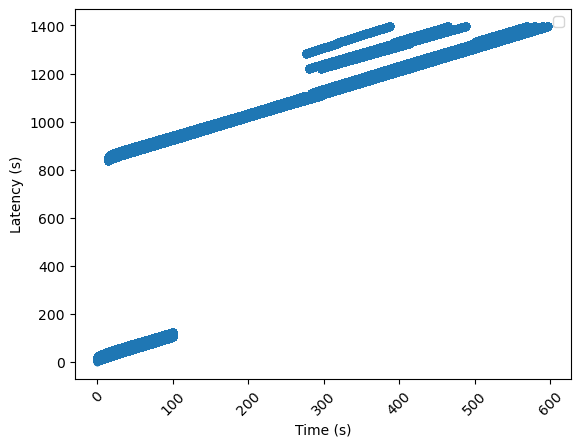

In [17]:
print(df["processed_time"].head())

df["processed_seconds"] = (
    df["processed_time"].dt.second +
    df["processed_time"].dt.microsecond / 1e6
)

print(df["processed_seconds"].head())

df["event_time_sec"] = (
    df["event_time"].dt.minute * 60 +
    df["event_time"].dt.second +
    df["event_time"].dt.microsecond / 1e6
)

t0 = df["event_time_sec"].min()
t0p = df["processed_seconds"].min()

df["event_time_sec_norm"] = df["event_time_sec"] - t0
df["processed_seconds_norm"] = df["processed_seconds"] - t0p
df["processed_seconds_norm"] = df["processed_seconds_norm"] * 60

df.plot(x="event_time_sec_norm", y="processed_seconds_norm", kind="scatter")

df["latency_ms"] = (df["processed_seconds_norm"] - df["event_time_sec_norm"])

df["window"] = df["event_time_sec_norm"].astype(int)

agg = df.groupby("window")["latency_ms"].agg(
    mean="mean",
    p95=lambda x: np.percentile(x, 95),
    p99=lambda x: np.percentile(x, 99)
).reset_index()

#plt.plot(agg["window"], agg["mean"], label="mean")
#plt.plot(agg["window"], agg["p95"], label="p95")
#plt.plot(agg["window"], agg["p99"], label="p99")

plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [9]:
print("\n================ LATENCY SUMMARY ================\n")
stats = compute_latency_summary(df)

print(f"  Avg latency : {stats['avg']:.2f} ms")
print(f"  P50 latency : {stats['p50']:.2f} ms")
print(f"  P95 latency : {stats['p95']:.2f} ms")
print(f"  P99 latency : {stats['p99']:.2f} ms")
print()


================ LATENCY SUMMARY ================

  Avg latency : 706.22 ms
  P50 latency : 823.92 ms
  P95 latency : 933.82 ms
  P99 latency : 1009.98 ms



In [10]:
print(df.keys())

print(df["processed_time"].head()) 
print(df["event_time"].head())

Index(['auction', 'bidder', 'price', 'event_time', 'processed_time', 'extra',
       'latency_ms', 'processed_seconds', 'event_time_sec',
       'event_time_sec_norm', 'processed_seconds_norm', 'window'],
      dtype='object')
0   2026-04-18 15:05:40.064000+00:00
1   2026-04-18 15:05:40.166000+00:00
2   2026-04-18 15:05:40.167000+00:00
3   2026-04-18 15:05:40.167000+00:00
4   2026-04-18 15:05:40.167000+00:00
Name: processed_time, dtype: datetime64[ns, UTC]
0   2026-04-18 19:05:36.028000+00:00
1   2026-04-18 19:05:36.029000+00:00
2   2026-04-18 19:05:36.030000+00:00
3   2026-04-18 19:05:36.030000+00:00
4   2026-04-18 19:05:36.031000+00:00
Name: event_time, dtype: datetime64[ns, UTC]


In [11]:
# ===================== ANALYSIS =====================
def smooth(series, w=5):
    return series.rolling(w, min_periods=1).mean()

def compute_latency(df):
    r = df["latency_ms"].resample(f"{window_seconds}s")
    return pd.DataFrame({
        "p50": r.quantile(0.5),
        "p95": r.quantile(0.95),
        "p99": r.quantile(0.99),
    })

def compute_throughput(df):
    return df["auction"].resample(f"{window_seconds}s").size()

def detect_failures(tp):
    gaps = []
    start = None

    for ts, v in tp.items():
        if v == 0 and start is None:
            start = ts
        elif v > 0 and start is not None:
            gaps.append((start, ts))
            start = None

    return gaps

In [12]:
# ===================== PLOTTING =====================
print("[PLOT] Latency plot...")
plt.figure()

node_colors = {"n0": "blue", "n1": "orange"}
all_failures = []

[PLOT] Latency plot...


<Figure size 640x480 with 0 Axes>

In [13]:
for node, df in node_data.items():
    lat = compute_latency(df)

    plt.plot(smooth(lat["p50"]), label=f"{node} p50")
    plt.plot(smooth(lat["p95"]), linestyle="--", label=f"{node} p95", color=node_colors.get(node))
    plt.plot(smooth(lat["p99"]), linestyle=":", label=f"{node} p99", color=node_colors.get(node))

plt.title(f"Latency ({query})")
plt.xlabel("Time")
plt.ylabel("ms")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / f"latency_{query}.png")
plt.close()

print("[PLOT] Throughput plot...")
plt.figure()

NameError: name 'node_data' is not defined

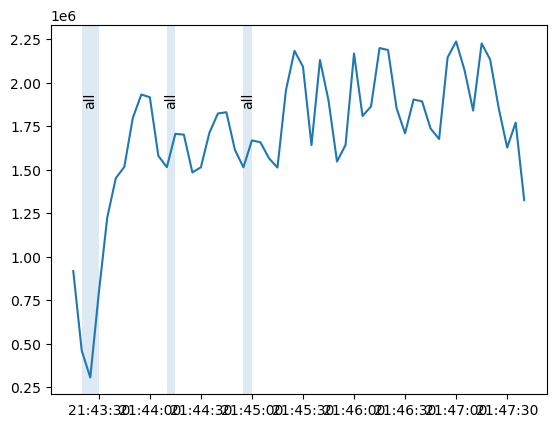

In [ ]:
for node, df in node_data.items():
    tp = compute_throughput(df)
    tp_s = smooth(tp)

    plt.plot(tp_s, label=node, color=node_colors.get(node))

    gaps = detect_failures(tp)
    for start, end in gaps:
        all_failures.append((start, end, node))

for start, end, node in all_failures:
    plt.axvspan(start, end, alpha=0.15, color=node_colors.get(node))
    mid = start + (end - start) / 2
    plt.text(mid, plt.ylim()[1] * 0.8, f"{node}", rotation=90, ha="center")

In [ ]:
plt.title(f"Throughput ({query})")
plt.xlabel("Time")
plt.ylabel("events/sec")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / f"throughput_{query}.png")
plt.close()

print("[COMPLETE] Done. Outputs in:", output_dir)

[COMPLETE] Done. Outputs in: /srv/nfs/flink/nexmark/normal/q1


/tmp/ipykernel_19035/3772911770.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [ ]:
df.head(2)

,auction,bidder,price,event_time,extra,latency_ms
processed_time,,,,,,
2026-04-17 21:43:17.221,1006,1006,4726675.720,2026-04-18 01:43:13.434,UTH]^OchxumfhhksgtJMV\R`lqyqpflckrcuyqdrjmjjsk...,3787.0
2026-04-17 21:43:17.237,8498,8498,1244.868,2026-04-18 01:43:13.434,UMa^LZNtvquvkJNLPM\NSMHRUVOR]P]djskerOT`V[Lgmb...,3803.0
